# Induction emergence — Phase 2 full sweep (40 cells × 3 sizes)

**Phase 2 deliverable.** 40-cell extension of the Phase 1 6-cell preview (`induction_emergence_exploration.ipynb`, kept as a historical artifact). Same Olsson prefix-matching detector (threshold > 0.3 per `PROJECT_BRIEF.md` §4); 40 log-spaced checkpoints from `step0` to `step143000` per `HYPOTHESIS.md` §H2-1; prompt-bootstrap CIs on μ per §H2-2; threshold-sensitivity bracket ± 25% in 5 increments per §H2-2.

**Locked thresholds:**
- Detection threshold: prefix-matching score > 0.3 (locked in brief).
- Bootstrap: per-sequence resampling, B = 1000, 95% percentile CI.
- Tiered fit handling: emerged (max ≥ 5), marginal (2 ≤ max < 5, bootstrap-median), censored (max < 2 → μ = step143000).


## Setup

In [1]:
import os
os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')

import sys
from pathlib import Path
REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from notebooks._lib.sweep_io import read_long
from src.analysis.phase2_logistic import tiered_fit, RIGHT_CENSOR_STEP
from src.analysis.phase2_bootstrap import (
    bootstrap_induction, summarize_bootstrap, threshold_sensitivity_curve,
    THRESHOLD_SENSITIVITY_FRACTIONS,
)

SIZES = ['70m', '160m', '410m']
SIZE_COLOR = {'70m': 'tab:blue', '160m': 'tab:orange', '410m': 'tab:green'}
INDUCTION_THRESHOLD = 0.3

## Load sweep data

Long-format parquet from `_run_phase2_induction_sweep.py`. Per-cell `.npz` with per-sequence scores for bootstrap is in `data/exploration/phase2_induction_per_seq/`.

In [2]:
df = read_long(REPO / 'data' / 'exploration' / 'phase2_induction_sweep.parquet')
print(f'Total rows: {len(df):,}')
print(f'Sizes: {sorted(df["size"].unique().tolist())}')
print(f'Steps: {sorted(df.step.unique().tolist())[:5]}...{sorted(df.step.unique().tolist())[-3:]}')
STEPS = sorted(df.step.unique().tolist())
print(f'N cells per size: {len(STEPS)}')
print(f'Heads per (size, step):')
print(df.groupby(['size', 'step']).size().unstack().iloc[:, :3].to_string())

Total rows: 23,040
Sizes: ['160m', '410m', '70m']
Steps: [0, 1, 2, 4, 8]...[100000, 120000, 143000]
N cells per size: 40
Heads per (size, step):
step    0    1    2
size               
160m  144  144  144
410m  384  384  384
70m    48   48   48


## Per-cell summary: count of induction heads (score > 0.3)

In [3]:
summary_rows = []
for (size, step), grp in df.groupby(['size', 'step']):
    scores = grp['score'].values
    n_above = int((scores > INDUCTION_THRESHOLD).sum())
    max_idx = int(np.argmax(scores))
    top_row = grp.iloc[max_idx]
    summary_rows.append(dict(
        size=size, step=step,
        n_above_03=n_above,
        max_score=float(scores.max()),
        top_layer=int(top_row['layer']), top_head=int(top_row['head']),
    ))
summary = pd.DataFrame(summary_rows)
summary['size'] = pd.Categorical(summary['size'], categories=SIZES, ordered=True)
summary = summary.sort_values(['size', 'step']).reset_index(drop=True)
print(summary.to_string(index=False))

size   step  n_above_03  max_score  top_layer  top_head
 70m      0           0   0.015156          4         5
 70m      1           0   0.015156          4         5
 70m      2           0   0.015156          4         5
 70m      4           0   0.015164          4         5
 70m      8           0   0.015258          4         5
 70m     16           0   0.015461          4         5
 70m     32           0   0.016954          4         5
 70m     64           0   0.016650          5         2
 70m    128           0   0.014217          3         4
 70m    256           0   0.013929          0         6
 70m    512           0   0.020547          4         6
 70m   1000           6   0.952662          3         6
 70m   2000           5   0.972152          3         6
 70m   3000           5   0.977459          3         6
 70m   4000           5   0.974489          3         6
 70m   5000           5   0.979112          3         6
 70m   6000           5   0.973803          3   

## Emergence curves with bootstrap CI on μ

Per Pythia size, count of heads with prefix-matching score > 0.3 over training. Logistic fit applied per §H2-3 tiered handling; emergence step μ extracted; B = 1000 prompt-bootstrap CI on μ at 95%.

In [4]:
rng = np.random.default_rng(0)
fits = {}
boots = {}
for size in SIZES:
    sub = summary[summary['size'] == size].sort_values('step')
    steps = sub['step'].values
    counts = sub['n_above_03'].values
    # Load per-seq cache
    per_seq_by_step = {}
    for s in steps:
        npz = np.load(REPO / 'data' / 'exploration' / 'phase2_induction_per_seq' / f'{size}_step{s}.npz')
        per_seq_by_step[int(s)] = npz['per_sequence_scores']
    mus, mu_point = bootstrap_induction(per_seq_by_step, INDUCTION_THRESHOLD, rng, B=1000)
    bres = summarize_bootstrap(size, 'induction', INDUCTION_THRESHOLD, mus, mu_point)
    fr = tiered_fit(size, 'induction', steps, counts)
    fits[size] = fr
    boots[size] = bres
    print(f'{size}: regime={fr.regime}, μ_point={fr.mu:.0f}, '
          f'μ_boot=[{bres.mu_ci_low:.0f}, {bres.mu_ci_high:.0f}] (95% CI)')

70m: regime=emerged, μ_point=641, μ_boot=[640, 641] (95% CI)


160m: regime=emerged, μ_point=6087, μ_boot=[4571, 9197] (95% CI)


410m: regime=emerged, μ_point=1621, μ_boot=[1543, 1728] (95% CI)


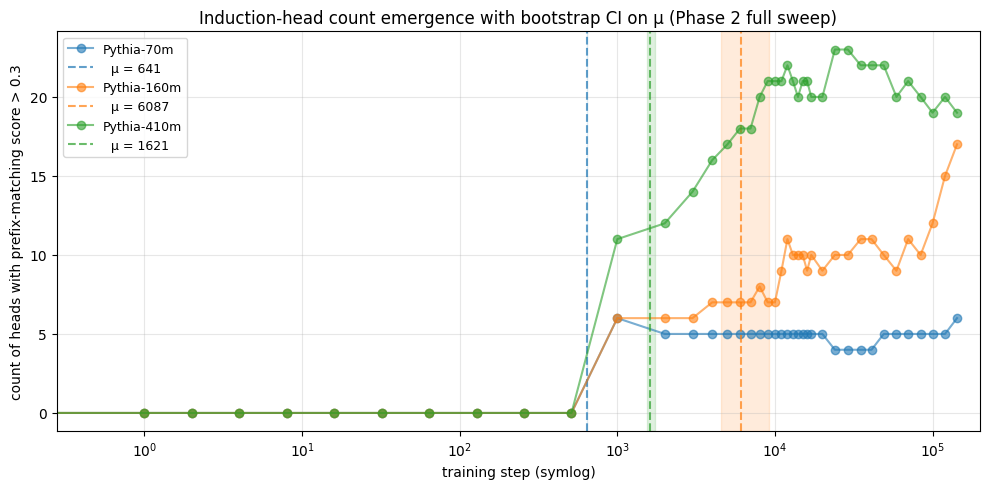

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
for size in SIZES:
    sub = summary[summary['size'] == size]
    ax.plot(sub['step'], sub['n_above_03'], marker='o', alpha=0.6,
            color=SIZE_COLOR[size], label=f'Pythia-{size}')
    bres = boots[size]
    if np.isfinite(bres.mu_point_estimate) and bres.mu_point_estimate < RIGHT_CENSOR_STEP - 1:
        ax.axvspan(bres.mu_ci_low, bres.mu_ci_high, alpha=0.15,
                   color=SIZE_COLOR[size])
        ax.axvline(bres.mu_point_estimate, color=SIZE_COLOR[size],
                   linestyle='--', alpha=0.7,
                   label=f'  μ = {bres.mu_point_estimate:.0f}')
ax.set_xscale('symlog', linthresh=1)
ax.set_xlim(0.5, 200000)
ax.set_xlabel('training step (symlog)')
ax.set_ylabel('count of heads with prefix-matching score > 0.3')
ax.set_title('Induction-head count emergence with bootstrap CI on μ (Phase 2 full sweep)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## (Layer, head) heatmap grid over training

Per-cell (layer, head) prefix-matching score. Bright cells = induction-candidate heads. With 40 cells the spatial-emergence trajectory is visible at finer resolution than the 6-cell preview.

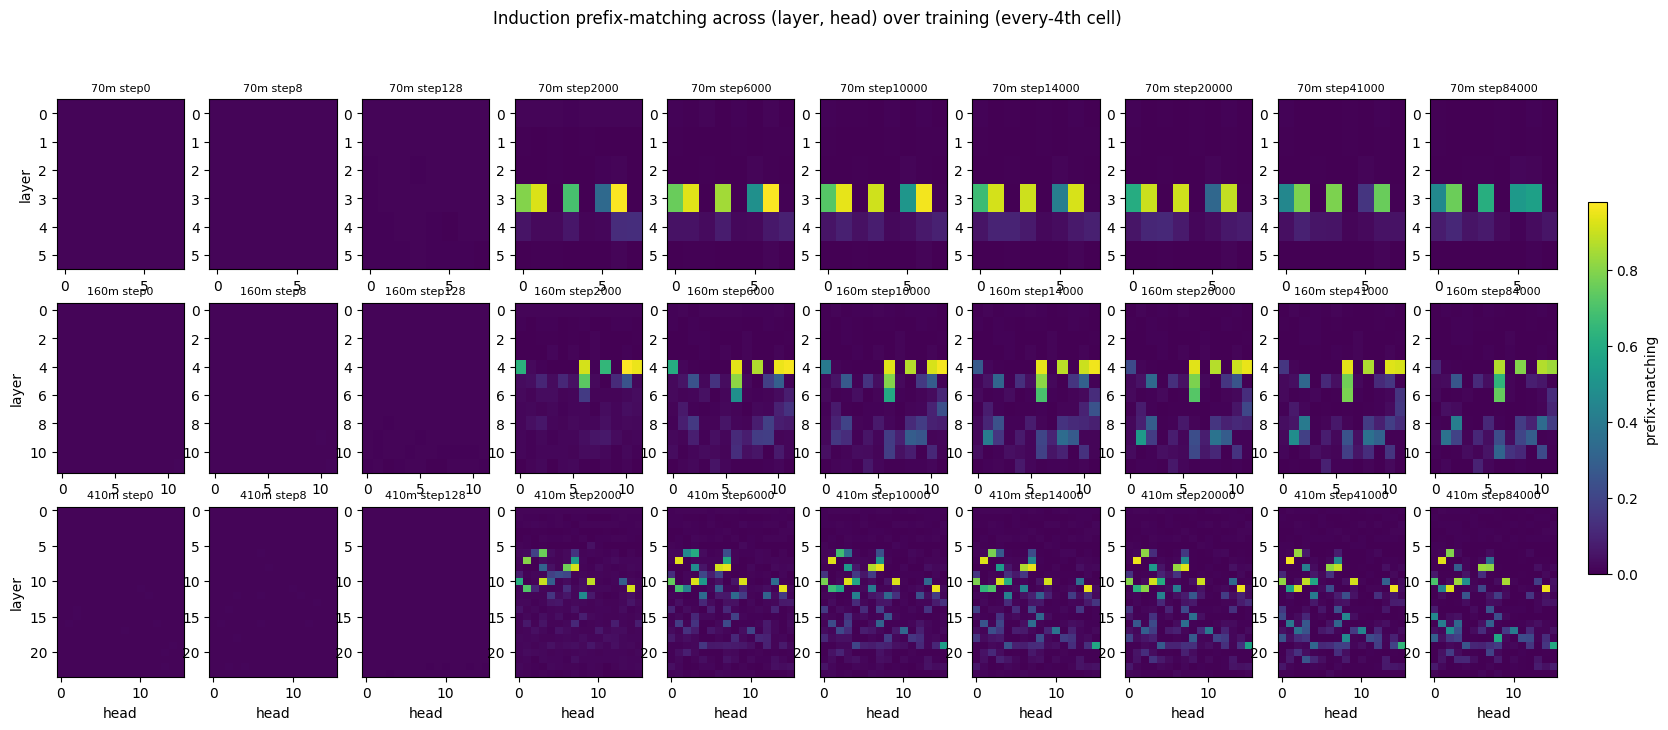

In [6]:
# 3 sizes × 40 steps is too dense for one grid; show every 4th step
PLOT_STEPS = STEPS[::4]
vmax = float(df['score'].max())
fig, axes = plt.subplots(
    nrows=len(SIZES), ncols=len(PLOT_STEPS),
    figsize=(2 * len(PLOT_STEPS), 2.5 * len(SIZES)),
)
for row, size in enumerate(SIZES):
    for col, step in enumerate(PLOT_STEPS):
        ax = axes[row][col]
        sub = df[(df['size'] == size) & (df['step'] == step)]
        if sub.empty:
            ax.set_visible(False); continue
        n_layers = int(sub['layer'].max() + 1)
        n_heads = int(sub['head'].max() + 1)
        grid = np.zeros((n_layers, n_heads))
        for _, r in sub.iterrows():
            grid[int(r['layer']), int(r['head'])] = r['score']
        im = ax.imshow(grid, vmin=0, vmax=vmax, cmap='viridis', aspect='auto')
        ax.set_title(f'{size} step{step}', fontsize=8)
        if col == 0: ax.set_ylabel('layer')
        if row == len(SIZES) - 1: ax.set_xlabel('head')
fig.suptitle('Induction prefix-matching across (layer, head) over training (every-4th cell)', y=1.0)
fig.colorbar(im, ax=axes, fraction=0.012, pad=0.02, label='prefix-matching')
plt.show()

## Threshold-sensitivity bracket per §H2-2

Vary the locked threshold (0.3) by ± 25% in 5 increments and report the resulting μ for each. Documents how robust the emergence-step estimate is to threshold mis-specification.

In [7]:
rng = np.random.default_rng(1)
rows = []
for size in SIZES:
    sub = summary[summary['size'] == size].sort_values('step')
    steps = sub['step'].values
    per_seq_by_step = {}
    for s in steps:
        npz = np.load(REPO / 'data' / 'exploration' / 'phase2_induction_per_seq' / f'{size}_step{s}.npz')
        per_seq_by_step[int(s)] = npz['per_sequence_scores']
    for frac in THRESHOLD_SENSITIVITY_FRACTIONS:
        thr = INDUCTION_THRESHOLD * (1.0 + frac)
        mus, mu_point = bootstrap_induction(per_seq_by_step, thr, rng, B=1)
        rows.append(dict(size=size, threshold=thr, fraction=frac, mu_point=mu_point))
sens_df = pd.DataFrame(rows)
print(sens_df.to_string(index=False))

size  threshold  fraction     mu_point
 70m     0.2250    -0.250   645.428833
 70m     0.2625    -0.125   640.530970
 70m     0.3000     0.000   640.530970
 70m     0.3375     0.125   637.731667
 70m     0.3750     0.250   637.531711
160m     0.2250    -0.250  2986.086423
160m     0.2625    -0.125  3819.858628
160m     0.3000     0.000  6086.867520
160m     0.3375     0.125  8602.493078
160m     0.3750     0.250 10001.376413
410m     0.2250    -0.250  2101.381233
410m     0.2625    -0.125  1742.522952
410m     0.3000     0.000  1620.856431
410m     0.3375     0.125  1599.497484
410m     0.3750     0.250  1558.615216


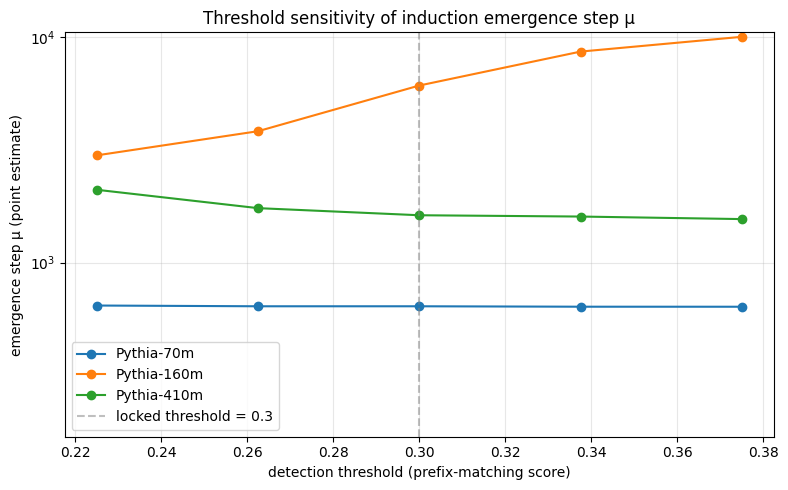

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
for size in SIZES:
    sub = sens_df[sens_df['size'] == size].sort_values('threshold')
    ax.plot(sub['threshold'], sub['mu_point'], marker='o',
            color=SIZE_COLOR[size], label=f'Pythia-{size}')
ax.axvline(INDUCTION_THRESHOLD, color='gray', linestyle='--', alpha=0.5,
           label=f'locked threshold = {INDUCTION_THRESHOLD}')
ax.set_xlabel('detection threshold (prefix-matching score)')
ax.set_ylabel('emergence step μ (point estimate)')
ax.set_yscale('symlog', linthresh=1)
ax.set_title('Threshold sensitivity of induction emergence step μ')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Verdict

Phase 2 deliverable for induction: 40-cell sweep complete, μ_{s,induction} extracted with bootstrap CI per (size). The induction emergence step provides the *first* term in the H1-C ordering test; the joint H1-C verdict is in `h1c_ordering_test.ipynb`.

Phase 1's 6-cell preview (`induction_emergence_exploration.ipynb`) remains on disk as a historical artifact for the chronology.